In [19]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import sys

sys.path.append("..")

from spatialrisk.dataset import Dataset
from spatialrisk.project import Project


## Set user parameters

In [21]:
project_name = "mtq-refactor"

# Load the project from JSON
project = Project.load(project_name=project_name)


Loaded 2 model(s)
✓ Target set: forest_loss_2015_2020 (static)
✓ Features set: 8 variables
  Static: altitude, protected_area, rivers_dist, roads_dist, slope, subj
  Temporal (year: 2015): forest_gfc, towns_dist
✓ Target set: forest_loss_2020_2024 (static)
✓ Features set: 8 variables
  Static: altitude, protected_area, rivers_dist, roads_dist, slope, subj
  Temporal (year: 2020): forest_gfc, towns_dist
Loaded 2 dataset(s)
Project loaded from: /home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/mtq-refactor_project.json
Loaded 23 processed variables


# Define/Load dataset

In [22]:
dataset = project.get_dataset("calibration")
dataset.validate()



🔍 Validating dataset configuration...
✓ Checking variable existence...
✓ All variables exist
✓ All variables processed and available
✓ Checking spatial compatibility...

✅ Dataset validation passed!


True

In [23]:
dataset.features

[LocalRasterVar(name='altitude', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/data/altitude_reprojected_matched.tif'), raster_type='continuous', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 LocalRasterVar(name='forest_gfc', data_type='raster', year=2015, active=True, tags=['forest'], path=PosixPath('/home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/data/forest_gfc_reprojected_matched_2015.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 LocalRasterVar(name='protected_area', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/data/protected_area_reprojected_matched.tif'), raster_

In [24]:
from spatialrisk.sampling import Sampling, SamplingStrategy

sampling = Sampling(
    strategy=SamplingStrategy.legacy,
    n_samples=10000,
    seed=33,  # for reproducibility
    adapt=True,
    pixel_area_ha=0.09,
)


In [25]:
model_identifier_name = "v1"
random_seed = 1


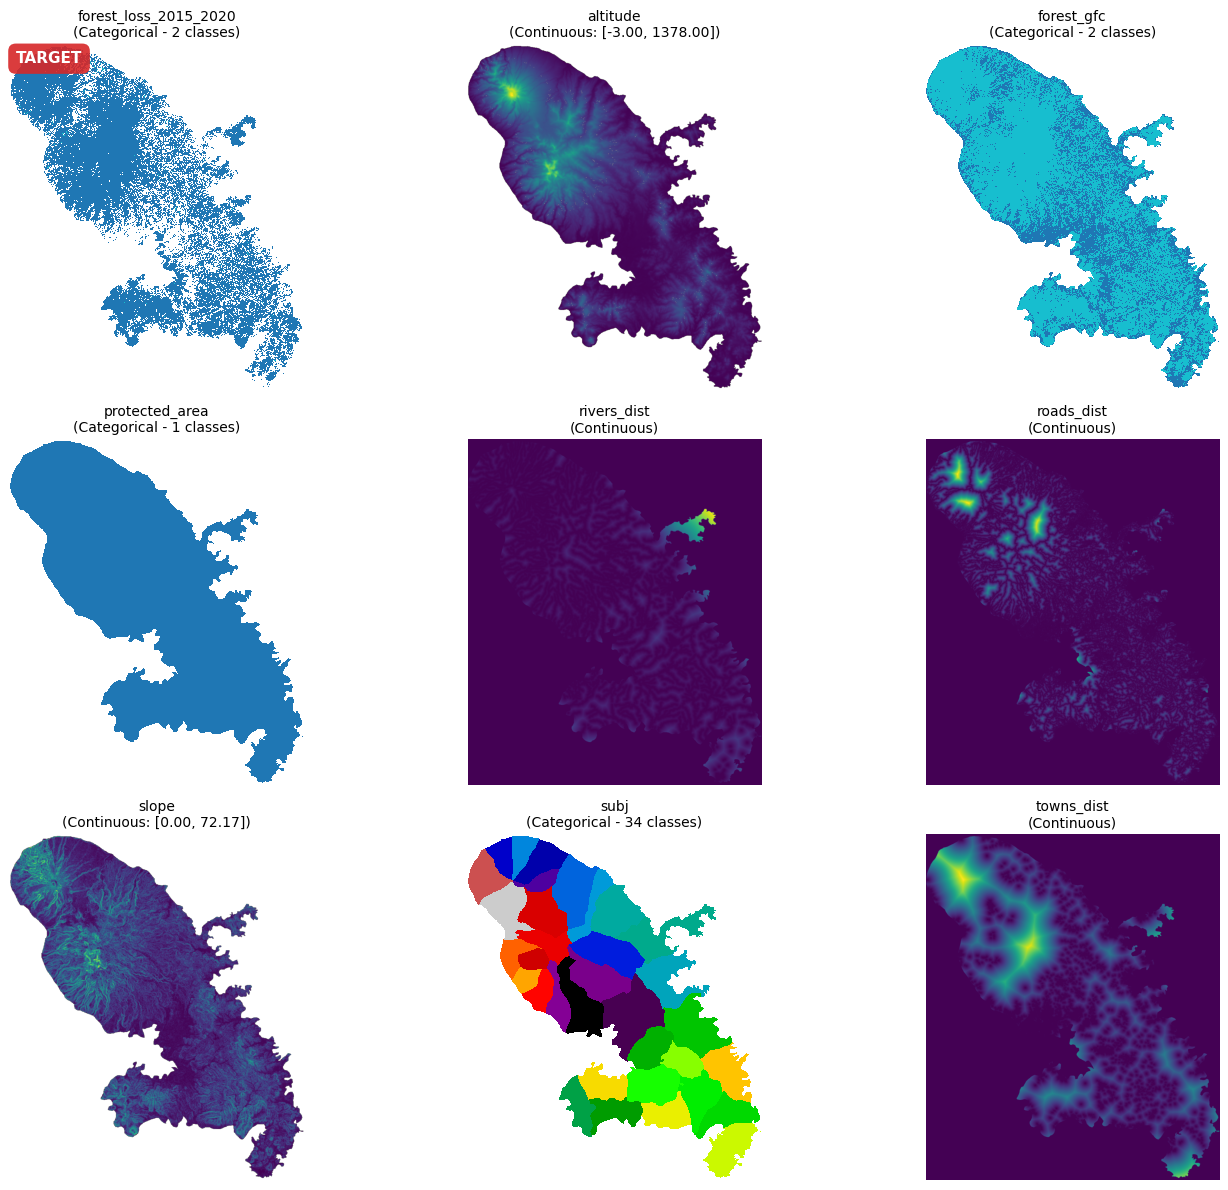


✅ Displayed 9 variable(s) in 3×3 grid


In [26]:
dataset.show()


In [27]:
samples_v1 = dataset.to_dataframe(sampling=sampling)
samples_v1



🔍 Validating dataset configuration...
✓ Checking variable existence...
✓ All variables exist
✓ All variables processed and available
✓ Checking spatial compatibility...

✅ Dataset validation passed!

📊 Creating DataFrame with SamplingStrategy.legacy sampling...
  Valid pixels: 846,547
  Adapted n_samples to 10,000 (total area: 0.076 Mha)
  Sampled 3,363 deforested + 10,000 forest = 13,363 total pixels (legacy)
✓ DataFrame created: 13,363 rows × 11 columns
  Target column: 'target' (from 'forest_loss_2015_2020')


,forest_loss_2015_2020,altitude,forest_gfc,protected_area,rivers_dist,roads_dist,slope,subj,towns_dist,cell_id,trial
0,1,100,1,0,90,30,3.784649,10,1350,30729,1
1,1,100,1,0,95,30,2.894564,10,1320,30730,1
2,1,101,1,0,108,0,4.296545,10,1290,30731,1
3,1,101,1,0,60,30,2.239622,10,1381,32252,1
4,1,100,1,0,90,60,1.452849,10,1351,32253,1
...,...,...,...,...,...,...,...,...,...,...,...
13358,0,595,1,0,180,242,42.331390,30,691,783711,1
13359,0,214,1,0,192,95,15.750842,9,218,363198,1
13360,0,190,1,0,0,95,5.441293,3,361,1215243,1
13361,0,66,1,0,218,108,16.535316,16,180,2213634,1


## Training formula


In [28]:
from spatialrisk.far_helpers import generate_patsy_formula


In [29]:
# user_formula = "I(1-fcc) + trial ~ scale(altitude) + scale(dist_edge) + scale(dist_river) + scale(dist_road) + scale(dist_town) + scale(slope) + C(pa)"
user_formula = None


In [30]:
calculated_formula = generate_patsy_formula(dataset)



📊 Generating Patsy formula:
  Target: forest_loss_2015_2020
  Features: altitude, forest_gfc, protected_area, rivers_dist, roads_dist, slope, subj, towns_dist
  Continuous: altitude, rivers_dist, roads_dist, slope, towns_dist
  Categorical: forest_gfc, protected_area, subj

✓ Formula: I(forest_loss_2015_2020) + trial ~ scale(altitude) + scale(rivers_dist) + scale(roads_dist) + scale(slope) + scale(towns_dist) + C(forest_gfc, levels=[0, 1]) + C(protected_area, levels=[0]) + C(subj, levels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34])



In [31]:
if user_formula is None:
    training_formula = calculated_formula
elif user_formula is not None:
    training_formula = user_formula
training_formula


'I(forest_loss_2015_2020) + trial ~ scale(altitude) + scale(rivers_dist) + scale(roads_dist) + scale(slope) + scale(towns_dist) + C(forest_gfc, levels=[0, 1]) + C(protected_area, levels=[0]) + C(subj, levels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34])'

## Train glm based on period

In [32]:
from spatialrisk import GLMModel, ICARModel, MWModel, RFModel

# model = GLMModel(
#     name="glm_v1", dataset=dataset, sampling=sampling, random_seed=random_seed
# )
model = RFModel(
    name="rf_v1", dataset=dataset, sampling=sampling, random_seed=random_seed
)
# model = ICARModel(
#     name="icarv1", dataset=dataset, sampling=sampling, random_seed=random_seed
# )
# model = MWModel(
#     name="mwmodel", dataset=dataset, sampling=sampling, random_seed=random_seed
# )
model.register(project)
model.fit()


  Model registered as project.models['rf_rf_v1']
Project saved to: /home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/mtq-refactor_project.json

🔍 Validating dataset configuration...
✓ Checking variable existence...
✓ All variables exist
✓ All variables processed and available
✓ Checking spatial compatibility...

✅ Dataset validation passed!

📊 Creating DataFrame with SamplingStrategy.legacy sampling...
  Valid pixels: 846,547
  Adapted n_samples to 10,000 (total area: 0.076 Mha)
  Sampled 3,363 deforested + 10,000 forest = 13,363 total pixels (legacy)
✓ DataFrame created: 13,363 rows × 11 columns
  Target column: 'target' (from 'forest_loss_2015_2020')
  Samples saved to: /home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_rf/samples_rf_rf_v1.csv

📊 Generating Patsy formula:
  Target: forest_loss_2015_2020
  Features: altitude, forest_gfc, protected_area, rivers_dist, roads_dist, slope, subj, towns_dist
  Continuous:

RFModel(name='rf_v1', model_type='rf', project_name='mtq-refactor', dataset_name=None, target_name='forest_loss_2015_2020', feature_names=['altitude', 'forest_gfc', 'protected_area', 'rivers_dist', 'roads_dist', 'slope', 'subj', 'towns_dist'], year=2015, formula='I(forest_loss_2015_2020) + trial ~ scale(altitude) + scale(rivers_dist) + scale(roads_dist) + scale(slope) + scale(towns_dist) + C(forest_gfc, levels=[0, 1]) + C(protected_area, levels=[0]) + C(subj, levels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34])', parameters={}, sampling=Sampling(strategy=<SamplingStrategy.legacy: 'legacy'>, n_samples=10000, seed=33, adapt=True, pixel_area_ha=0.09), model_path=PosixPath('/home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_rf/rf_rf_v1_20260605_005855.pickle'), samples_path=PosixPath('/home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_

In [33]:
paths = dataset.get_file_paths()
forest_gfc_path = paths["forest_gfc"]
forest_gfc_path


PosixPath('/home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/data/forest_gfc_reprojected_matched_2015.tif')

In [34]:
# output_file = project.folders.glm_model_folder / model.name / "glm_calibration5.tif"
output_file = project.folders.rf_model / model.name / "glm_calibration1.tif"
output_file2 = project.folders.rf_model / model.name / "glm_calibration1_no_mask.tif"

model.apply(output_file, dataset, forest_gfc_path, 0)
model.apply(output_file2, dataset)



🗺  Predicting RF raster → /home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_rf/rf_v1/glm_calibration1.tif
✓ RF raster written: /home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_rf/rf_v1/glm_calibration1.tif

🗺  Predicting RF raster → /home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_rf/rf_v1/glm_calibration1_no_mask.tif
✓ RF raster written: /home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_rf/rf_v1/glm_calibration1_no_mask.tif


PosixPath('/home/jserafini/Desktop/projects/spatial_risk/spatial-risk-module/data/mtq-refactor/far_rf/rf_v1/glm_calibration1_no_mask.tif')

In [ ]:
print(model.name)


In [ ]:
# Predict over historical period

period_c = "forecast"


model = get_trained_model(
    period_dictionaries, period_c, f"glm_model_{model_identifier_name}.pickle"
)

glm_predict_forecast = apply_glm_period(
    period_dictionaries,
    period_c,
    model,
)


In [ ]:
print("Done!")
